In [2]:
# Loading the Libraries 
from prophet import Prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data Import and Cleaning

In [3]:
#Basic Data Cleaning Function
def load_cleaning (filepath):
    # Loading the data
    df = pd.read_excel(filepath,sheet_name="Estimates",header=[1],skiprows=0)
    #Keep only rows that are actual countries/regions(drop empty)
    df = df[pd.to_numeric(df['Year'], errors='coerce').notna()]
    df['Year'] = df['Year'].astype(int)
    # Filter Kenya + region + peers
    countries = ['KEN','UGA', 'TZA', 'ETH']
    kenya_peers = df[df['Code'].isin(countries)].copy()
    kenya_peers['Country_Region'] = kenya_peers['Country_Region'].replace({'United Republic of Tanzania':'Tanzania'})
    return kenya_peers
    

In [9]:
# Loading and Cleaning data using the function.
kenya_peers = load_cleaning(r"D:\2026\Portfolio Data\HIV Estimates Data.xlsx")
kenya_peers.info()

<class 'pandas.DataFrame'>
Index: 140 entries, 1680 to 2134
Data columns (total 19 columns):
 #   Column                                                                                        Non-Null Count  Dtype 
---  ------                                                                                        --------------  ----- 
 0   Year                                                                                          140 non-null    int64 
 1   Code                                                                                          140 non-null    str   
 2   Country_Region                                                                                140 non-null    str   
 3   Adults (15-49) prevalence (%)-Estimate                                                        140 non-null    object
 4   Young women (15-24) prevalence (%)-Estimate                                                   140 non-null    object
 5   Young men (15-24) prevalence (%)- Estimate      

In [10]:
# A function to clean estimates recorded in millions to numbers e.g 1.1m to 1,100,000
def clean_estimate(x):
    x = str(x).lower().replace(',', '').strip()
    x = x.replace(' ', '')  # remove spaces
    
    if 'm' in x:
        return float(x.replace('m', '')) * 1_000_000
    else:
        return pd.to_numeric(x, errors='coerce')

#Apply it to multiple columns
cols = [
    'Adults and children newly infected with HIV- Estimate',
    'Adults (15+) newly infected with HIV- Estimate',
    'Estimated adults and children living with HIV- Estimate',
    'Estimated adults (15+) living with HIV- Estimate',
    'Estimated women (15+) living with HIV- Estimate',
    'Estimated children (0-14) living with HIV- Estimate',
    'AIDS-related deaths among adults and children- Estimate',
    'AIDS-related deaths among adults (15+)- Estimate'
]

kenya_peers[cols] = kenya_peers[cols].map(clean_estimate)

kenya_peers.info()

<class 'pandas.DataFrame'>
Index: 140 entries, 1680 to 2134
Data columns (total 19 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Year                                                                                          140 non-null    int64  
 1   Code                                                                                          140 non-null    str    
 2   Country_Region                                                                                140 non-null    str    
 3   Adults (15-49) prevalence (%)-Estimate                                                        140 non-null    object 
 4   Young women (15-24) prevalence (%)-Estimate                                                   140 non-null    object 
 5   Young men (15-24) prevalence (%)- Estimat

In [11]:

#Cleaning numerical variables and converting them to the correct data type

float_cols =[
    'Adults (15-49) prevalence (%)-Estimate',
    'Young women (15-24) prevalence (%)-Estimate',
    'Young men (15-24) prevalence (%)- Estimate',
    'Adults (15-49) incidence (per 1000 uninfected population) - Estimate',
    'All ages incidence (per 1000 uninfected population)- Estimate'    
]
kenya_peers[float_cols] = kenya_peers[float_cols].replace('<0.1', 0.05)
kenya_peers[float_cols] = kenya_peers[float_cols].astype(float)


whole_numbers = ['AIDS-related deaths among adults and children- Estimate',
                'AIDS-related deaths among children (0-14)- Estimate',
                'AIDS-related deaths among adults (15+)- Estimate',
                'Estimated children (0-14) living with HIV- Estimate',
                'Estimated women (15+) living with HIV- Estimate',
                'Estimated adults (15+) living with HIV- Estimate',
                'Estimated adults and children living with HIV- Estimate',
                'Pregnant women needing antiretrovirals for preventing mother-to-child transmission -Estimate',
                'Children (0-14) newly infected with HIV- Estimate',
                'Adults (15+) newly infected with HIV- Estimate',
                'Adults and children newly infected with HIV- Estimate']
kenya_peers[whole_numbers] = (
    kenya_peers[whole_numbers]
    .replace(r'[\s\xa0]', '', regex=True)
    .apply(pd.to_numeric, errors='coerce')
    .round()
    .astype('Int64')
)


kenya_peers.info()

<class 'pandas.DataFrame'>
Index: 140 entries, 1680 to 2134
Data columns (total 19 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Year                                                                                          140 non-null    int64  
 1   Code                                                                                          140 non-null    str    
 2   Country_Region                                                                                140 non-null    str    
 3   Adults (15-49) prevalence (%)-Estimate                                                        140 non-null    float64
 4   Young women (15-24) prevalence (%)-Estimate                                                   140 non-null    float64
 5   Young men (15-24) prevalence (%)- Estimat

In [12]:
# Renaming columns
kenya_peers.rename(columns={'Adults (15-49) prevalence (%)-Estimate':'adults(15-49)_prev(%)',
                           'Young women (15-24) prevalence (%)-Estimate':'women_18_24_Prev(%)',
                           'Young men (15-24) prevalence (%)- Estimate':'men_18_24_prev(%)',
                           'AIDS-related deaths among adults and children- Estimate':'total_deaths',
                           'AIDS-related deaths among children (0-14)- Estimate':'total_children_deaths',
                           'AIDS-related deaths among adults (15+)- Estimate':'total_adults_deaths',
                           'Estimated children (0-14) living with HIV- Estimate':'children_with_hiv',
                           'Estimated women (15+) living with HIV- Estimate':'women_with_hiv',
                           'Estimated adults (15+) living with HIV- Estimate':'adults_with_hiv(15+)',
                           'Estimated adults and children living with HIV- Estimate':'total_hiv_pop',
                           'Adults (15-49) incidence (per 1000 uninfected population) - Estimate':'adults_incidence_1000_uninfectedpop',
                           'All ages incidence (per 1000 uninfected population)- Estimate':'total_incidence_1000_uninfectedpop', 
                           'Pregnant women needing antiretrovirals for preventing mother-to-child transmission -Estimate':'preg_women_antiretrovirals',
                           'Children (0-14) newly infected with HIV- Estimate':'newly_infected_children',
                           'Adults (15+) newly infected with HIV- Estimate':'newly_infected_adults',
                           'Adults and children newly infected with HIV- Estimate':'total_newly_infected',
                           'Country_Region':'country'},inplace=True)
kenya_peers.head()

,Year,Code,country,adults(15-49)_prev(%),women_18_24_Prev(%),men_18_24_prev(%),total_deaths,total_children_deaths,total_adults_deaths,children_with_hiv,women_with_hiv,adults_with_hiv(15+),total_hiv_pop,adults_incidence_1000_uninfectedpop,total_incidence_1000_uninfectedpop,preg_women_antiretrovirals,newly_infected_children,newly_infected_adults,total_newly_infected
1680,1990,ETH,Ethiopia,2.2,2.3,0.7,20000,8700,11000,40000,250000,430000,470000,6.3,3.4,29000,20000,120000,140000
1681,1991,ETH,Ethiopia,2.6,2.7,0.8,26000,11000,15000,52000,320000,540000,590000,6.5,3.6,37000,24000,130000,150000
1682,1992,ETH,Ethiopia,3.0,3.0,0.8,33000,13000,20000,64000,380000,630000,700000,6.0,3.4,44000,26000,120000,150000
1683,1993,ETH,Ethiopia,3.3,3.1,0.8,40000,14000,26000,76000,430000,710000,790000,5.3,3.1,50000,28000,110000,140000
1684,1994,ETH,Ethiopia,3.4,3.1,0.8,47000,15000,31000,88000,460000,760000,850000,4.3,2.7,55000,29000,91000,120000


In [31]:
Eth_2010 = kenya_peers[(kenya_peers['Year']==2010) &( kenya_peers['Code']=='ETH')]
Eth_2010

,Year,Code,country,adults(15-49)_prev(%),women_18_24_Prev(%),men_18_24_prev(%),total_deaths,total_children_deaths,total_adults_deaths,children_with_hiv,women_with_hiv,adults_with_hiv(15+),total_hiv_pop,adults_incidence_1000_uninfectedpop,total_incidence_1000_uninfectedpop,preg_women_antiretrovirals,newly_infected_children,newly_infected_adults,total_newly_infected
20,2010,ETH,Ethiopia,1.4,0.7,0.4,27000,7700,19000,93000,360000,570000,660000,0.47,0.35,25000,8500,17000,26000


In [16]:
#Exporting the cleaned data for storage.
kenya_peers.to_csv(r"D:\2026\Portfolio Data\cleaned_hiv_data.csv",index=False)

# Descrptive and Exploratory Analysis

In [13]:
cols=[
    'Year',
    'country',
    'total_newly_infected',
    'adults_with_hiv(15+)',
    'adults(15-49)_prev(%)'
    ]
new_infections = kenya_peers[cols].set_index('Year').copy()
new_infections.head()

,country,total_newly_infected,adults_with_hiv(15+),adults(15-49)_prev(%)
Year,,,,
1990,Ethiopia,140000,430000,2.2
1991,Ethiopia,150000,540000,2.6
1992,Ethiopia,150000,630000,3.0
1993,Ethiopia,140000,710000,3.3
1994,Ethiopia,120000,760000,3.4


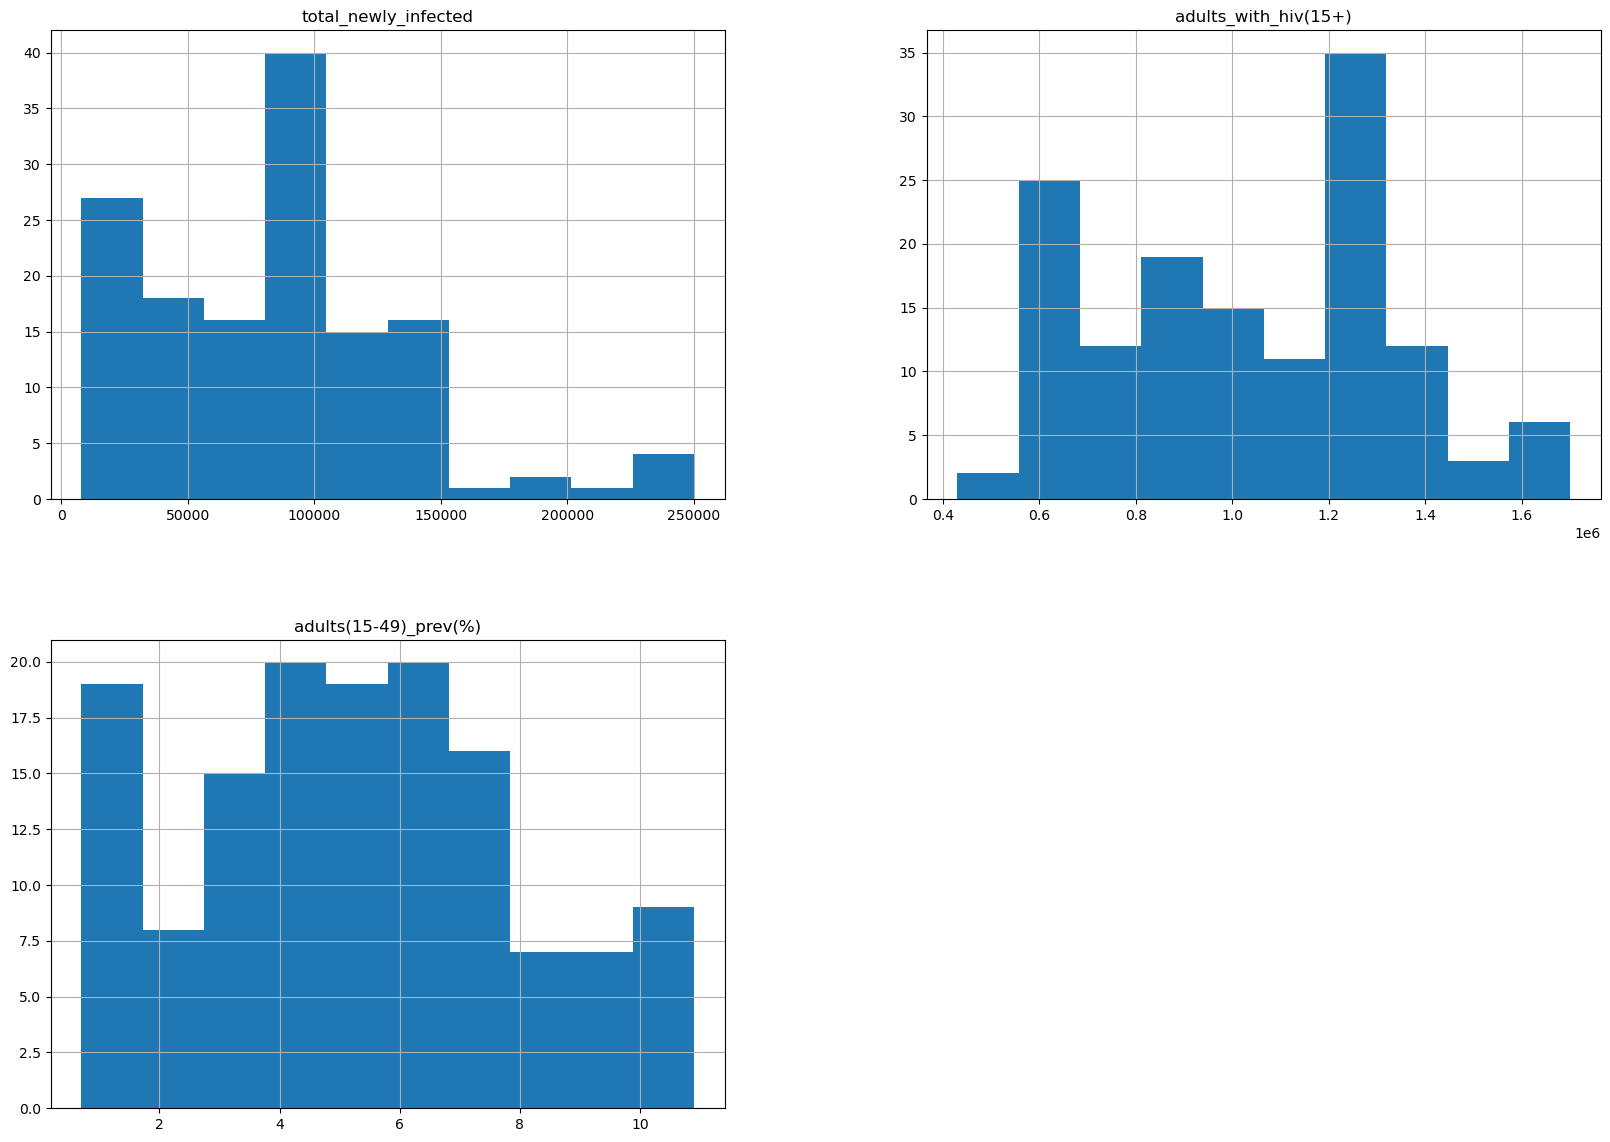

In [14]:
#Exploring the distribution of numeric columns
_=new_infections.hist(figsize=(20,14))

#### HIV INFECTION IN KENYA AND ITS PEERS

In [15]:
# Average Number of infections by country over the years(1990-2024)
new_infections.groupby('country')['total_newly_infected'].mean().sort_values(ascending=False)

country
Tanzania    104285.714286
Kenya       102542.857143
Uganda       85028.571429
Ethiopia     50525.714286
Name: total_newly_infected, dtype: Float64

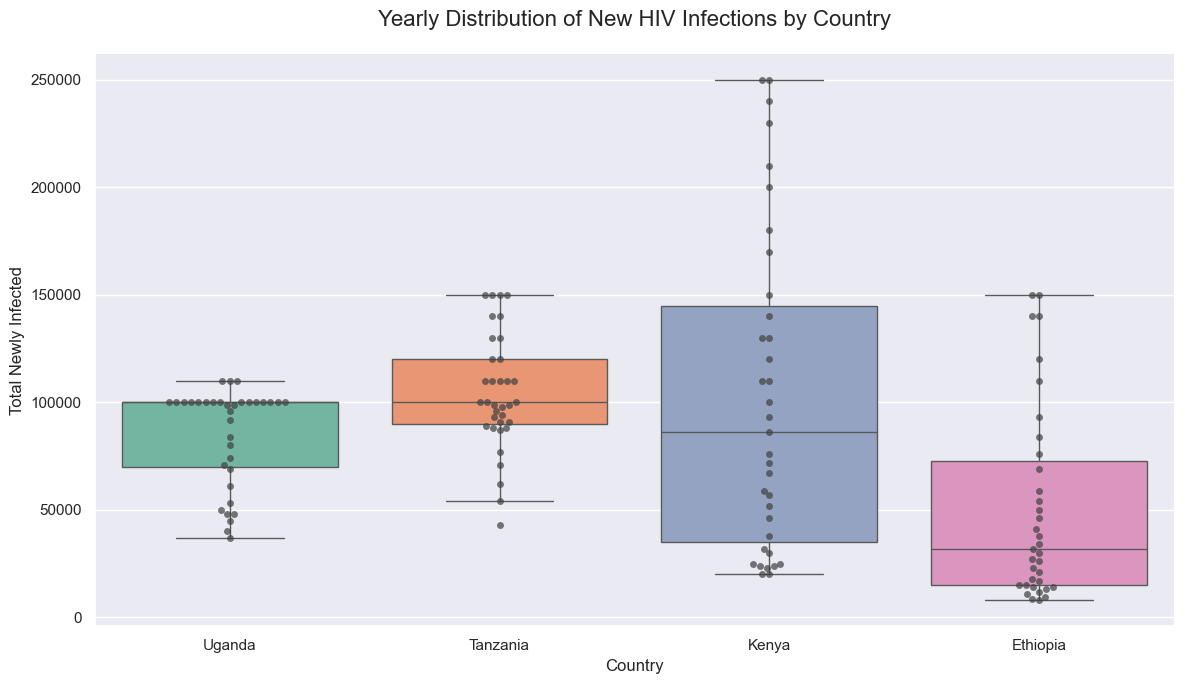

In [16]:
# PLOT SHOWING THE ANNUAL DISTRIBUTION OF NEW HIV INFECTIONS IN KENYA AND ITS PEERS.

fig=plt.figure(figsize=(12, 7))
sns.set_theme(style="darkgrid")

# 1. Calculate cases by countries
country_cases = kenya_peers.groupby('country')['total_newly_infected'].median().sort_values(ascending=False).index

# 2. Draw the boxplot (make it slightly lighter so dots stand out)
sns.boxplot(
    x='country', 
    y='total_newly_infected', 
    data=kenya_peers,
    order=country_cases,
    palette="Set2", 
    fliersize=0  # Hide outliers in boxplot to avoid double-plotting them with the dots
)

# 3. Add the "Swarm" of data points
sns.swarmplot(
    x='country', 
    y='total_newly_infected', 
    data=kenya_peers,
    order=country_cases,
    color="0.25", # Dark grey dots
    size=5,
    alpha=0.7
)

plt.title("Yearly Distribution of New HIV Infections by Country", fontsize=16, pad=20)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Total Newly Infected", fontsize=12)
sns.despine()

plt.savefig("Yearly_Distribution_of_New_HIV_Infections_by_Country.png", dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor())

plt.tight_layout()
plt.show()
 

The graph represents how new HIV infection rates have behaved over the years; the dots represent one year of data. Over the period from 1990 to 2024, there has been a massive difference between the "best" years and the "worst" years in Kenya and Ethiopia. In Kenya, for instance, new infections have swung from 250,000 to almost zero. The squashed-view boxplots of Uganda and Tanzania indicate that the numbers of new infections have stayed relatively consistent over the years. The concentration of the dots at the bottom of Kenya's and Ethiopia's boxplots indicates that the two countries have managed to significantly push down the number of new HIV infections in recent years. Uganda has a very flat cluster of dots at the top of its box. This means that the numbers haven't changed much for a long stretch of time, or where there is a "ceiling" on the reported data.

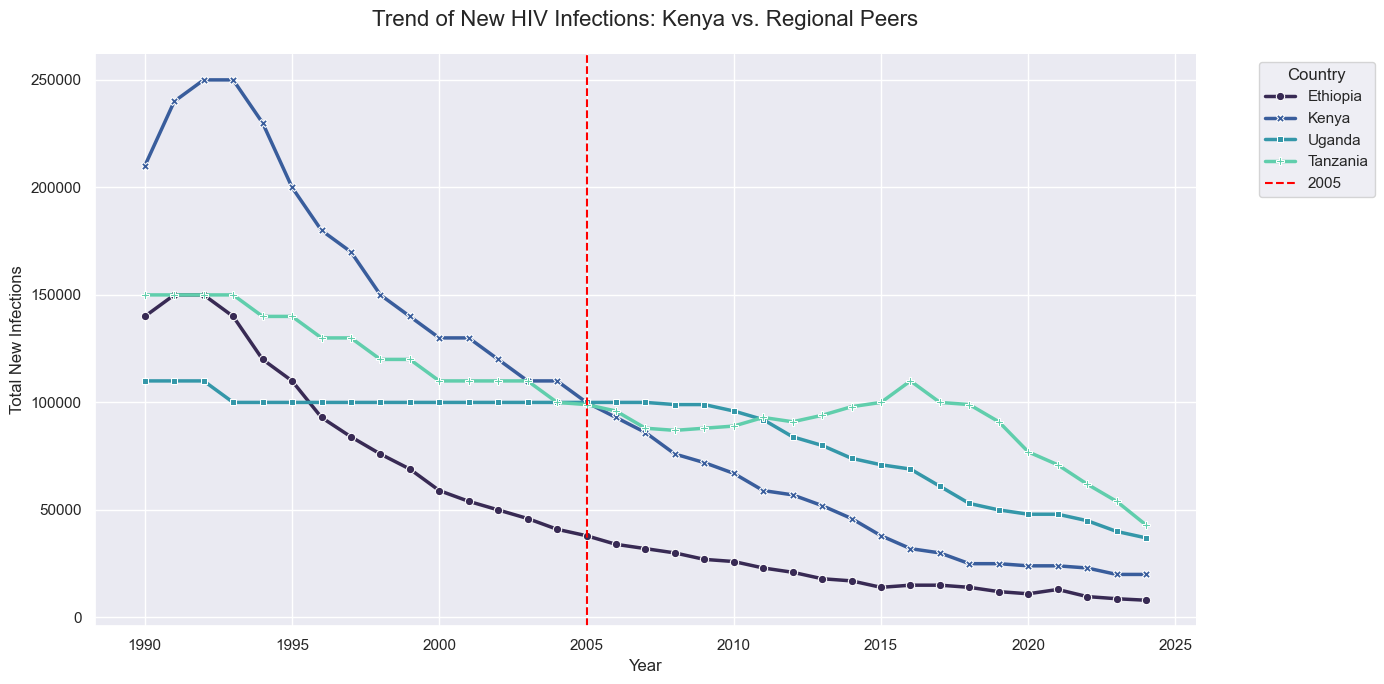

In [17]:
# Total number of new infections overtime
plt.figure(figsize=(14,7))
sns.set_theme(style="darkgrid")
sns.lineplot(
    data=new_infections,
    x='Year',
    y='total_newly_infected',
    hue='country',
    style='country',
    markers=True,
    dashes=False,
    linewidth=2.5,
    palette='mako',
    errorbar=None
)

# Add vertical line at 2005
plt.axvline(x=2005,color='red',linestyle='--',linewidth=1.5,label='2005')
plt.title("Trend of New HIV Infections: Kenya vs. Regional Peers", fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total New Infections", fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig("Trend_of_new_HIV_infections.png", dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()


Since the year 2005, new HIV infections have relatively stayed below the 100,000 mark. This is not a coincidence because in 2005, that is when the U.S. President's Emergency Plan for AIDS Relief (PEPFAR) became fully operational, injecting billions of dollars in HIV treatment and in partnership with Global Fund, provided free or low-cost generic ARVs that played a significant role in reducing the viral load in populations. It is also in the same year that programmes for the prevention of mother-to-child transmission (PMTCT) became standard in many African clinics. This led to a drastic drop in the number of babies born with HIV. All these efforts also aligned with the World Health Organization's (WHO) "3 by 5" initiative that aimed to get 3 million people on treatment by the end of 2005.

In [18]:
#HIV NEW INFECTIONS PERCENT CHANGE(2005 VS 2024)

# Filter for just the two years we care about
years_of_interest = kenya_peers[kenya_peers['Year'].isin([2005, 2024])]

# Pivot the data so we have a column for 2005 and a column for 2024
pivot_df = years_of_interest.pivot(index='country', columns='Year', values='total_newly_infected')

# Calculate the percent change
pivot_df['pct_change'] = ((pivot_df[2024] - pivot_df[2005]) / pivot_df[2005]) * 100

# Reset index to make 'country' a column again for plotting
plot_data = pivot_df.reset_index().sort_values('pct_change')

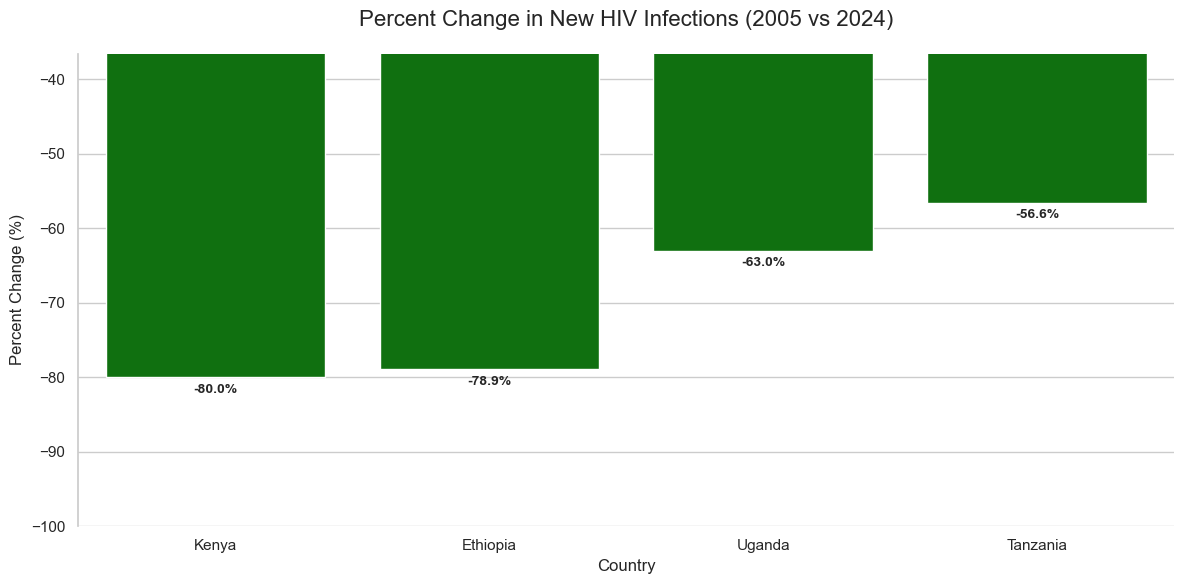

In [19]:
# Plot the data

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create the barplot
# Using a diverging palette (Red for increase, Green for decrease)
colors = ['red' if x > 0 else 'green' for x in plot_data['pct_change']]

ax = sns.barplot(
    x='country', 
    y='pct_change', 
    data=plot_data, 
    palette=colors
)

# Add a horizontal line at 0 for reference
plt.axhline(0, color='black', linewidth=1)

# Add text labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9) if p.get_height() > 0 else (0, -9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.title("Percent Change in New HIV Infections (2005 vs 2024)", fontsize=16, pad=20)
plt.ylabel("Percent Change (%)")
plt.xlabel("Country")

# Set Y-axis limits slightly wider to accommodate labels
plt.ylim(plot_data['pct_change'].min() - 20, plot_data['pct_change'].max() + 20)

sns.despine(bottom=True)
plt.tight_layout()
plt.show()

Comparing 2005 and 2024(19yrs), Kenya and Ethiopia have reduced the number of new HIV infections at a higher rate compared to the rest of the countries.

#### ASSESSING HIV PREVELENCE AND THE POPULATION LIVING WITH HIV IN KENYA AND ITS REGIONAL PEERS.

The prevelence of HIV/AIDS  is a measure of the total burden of the disease, representing the total number of both new and old cases. It creates a clear picture of how common the disease is and is expressed as a percentage of the population at risk.

In [20]:
new_infections = new_infections.reset_index()
prevelence_post_2005 = new_infections[new_infections['Year']>=2005]


In [21]:
# Average HIV prevalence by country - Weighted average will be the most ideal because the population in these countries are not the same, 
#therefore, a simple average will be misleading

# Step 1: Back-calculate total population from the two columns you have
prevelence_post_2005['total_population'] = prevelence_post_2005['adults_with_hiv(15+)'] / (prevelence_post_2005['adults(15-49)_prev(%)'] / 100)

# Step 2: Weighted average prevalence per year (across all countries)
weighted_avg = (
    prevelence_post_2005
    .groupby('country')
    .apply(lambda x: (x['adults(15-49)_prev(%)'] * x['total_population']).sum() / x['total_population'].sum())
    .reset_index(name='weighted_avg_prevalence')
)

# Step 3: Overall single weighted average (across all years and countries)
overall_weighted_avg = (
    (prevelence_post_2005['adults(15-49)_prev(%)'] * prevelence_post_2005['total_population']).sum() /
    prevelence_post_2005['total_population'].sum()
)

print(weighted_avg)
print(f"\nOverall Weighted Average Prevalence: {overall_weighted_avg:.2f}%")

    country  weighted_avg_prevalence
0  Ethiopia                 1.082673
1     Kenya                 4.453627
2  Tanzania                 4.279619
3    Uganda                 6.338712

Overall Weighted Average Prevalence: 3.31%


**Uganda — 6.34% (Highest)**
Uganda carries the heaviest HIV burden in this peer group. This means roughly 1 in 16 people in Uganda are living with HIV on average across the study period (2005-2024). Despite Uganda being one of the earliest African success stories in HIV response in the 1990s, prevalence has remained stubbornly high.

**Kenya — 4.45% (Second highest)**
Kenya's prevalence of 4.45% is well above the global average of ~0.7%, meaning roughly 1 in 22 people are living with HIV. This is particularly concerning given Kenya's large population, meaning the absolute number of people affected is substantial.

**Tanzania — 4.27% (Third)**
Tanzania sits in the middle of the group at 4.27%, meaning roughly 1 in 23 people are living with HIV/AIDS. This is still a significant burden but notably lower than Uganda's. This suggests Tanzania's prevention and treatment programmes may have had relatively more impact proportionally. This near-parity between Kenya and Tanzania suggests that the two countries face a similarly scaled epidemic and could benefit from shared regional strategies.

**Ethiopia — 1.08% (Lowest)**
Ethiopia stands far apart from its peers at just 1 in 92 people — making it nearly 6 times less affected than Uganda over the same period. This is partly explained by Ethiopia's larger population diluting the rate but also reflects cultural, geographic, and programmatic factors that have kept transmission comparatively lower.

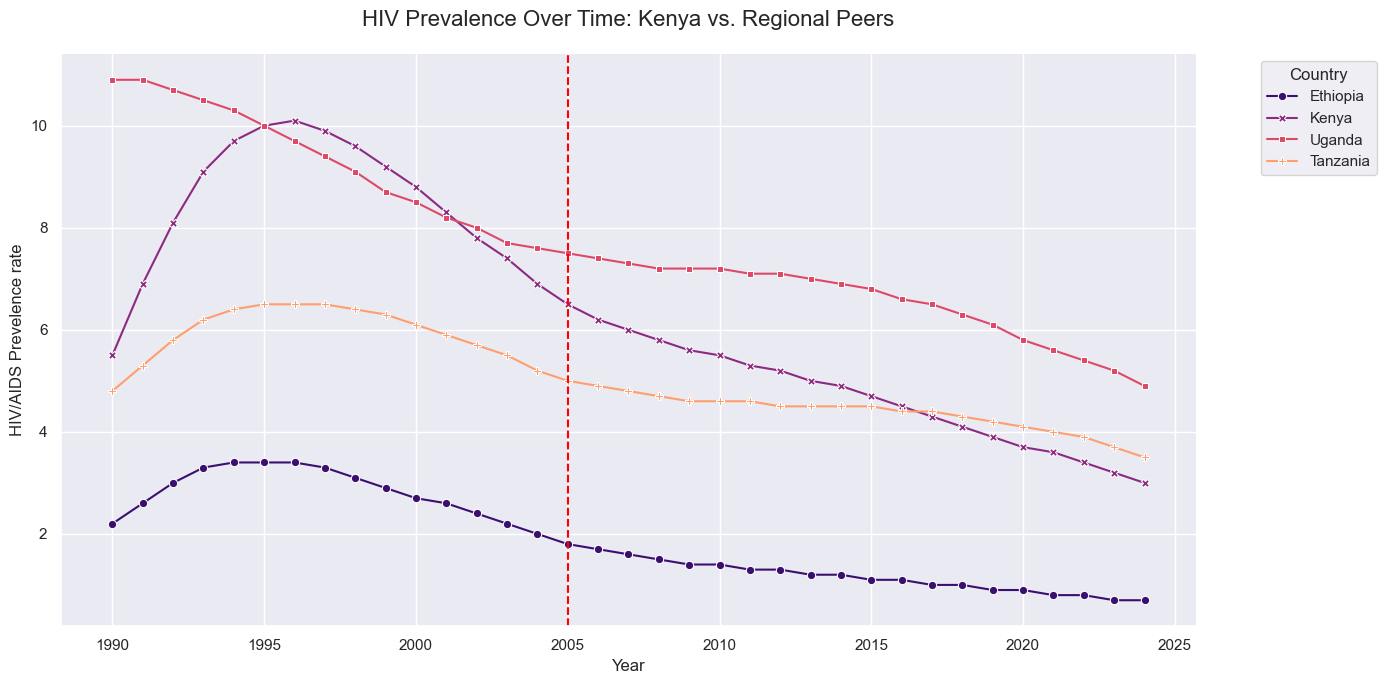

In [22]:
# Line chart showing prevelence over the years(1990-2024)
plt.figure(figsize=(14,7))
sns.set_theme(style='darkgrid')

sns.lineplot(
    data=new_infections,
    x='Year',
    y='adults(15-49)_prev(%)',
    hue = 'country',
    style='country',
    palette ='magma',
    markers=True,
    dashes = False,
    
)
# Add vertical line at 2005
plt.axvline(x=2005,color='red',linestyle='--',linewidth=1.5)
plt.title("HIV Prevalence Over Time: Kenya vs. Regional Peers", fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("HIV/AIDS Prevelence rate", fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig("HIV_Prevelence_overtime.png", dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()

# ART COVERAGE
**The UNAIDS**  95-95-95 target aims to ensure 95% of people living with HIV know their status, 95% of those diagnosed receive antiretroviral therapy (ART), and 95% of those on treatment achieve viral suppression. While it was initially a milestone for 2025, UNAIDS has extended and re-anchored it as the definitive benchmark for ending the AIDS epidemic by 2030.

In [46]:
# ART COVERAGE POST 2010

#loading Data
arv_coverage = pd.read_excel(r"C:\Users\MOTE THE ANALYST\Forecasting-HIV-new-infections-and-ART-coverage-in-Kenya-vs.-peer-countries\HIV Estimates Data.xlsx",sheet_name="ART_Coverage",header=[0])
print(f"this data covers from {arv_coverage['Year'].min()}, to {arv_coverage['Year'].max()}")

this data covers from 2010, to 2024


In [47]:
# Data inspection
arv_coverage.info()

#Set 'year' as index
arv_coverage.set_index('Year',inplace=True)

arv_coverage['country'] = arv_coverage['country'].replace({'United Republic of Tanzania':'Tanzania'})

#View first 5 rows
arv_coverage.head()


<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Year          60 non-null     int64
 1   code          60 non-null     str  
 2   country       60 non-null     str  
 3   PLHIV_ARV(%)  60 non-null     int64
dtypes: int64(2), str(2)
memory usage: 2.9 KB


,code,country,PLHIV_ARV(%)
Year,,,
2010,ETH,Ethiopia,33
2010,KEN,Kenya,31
2010,UGA,Uganda,20
2010,TZA,Tanzania,20
2011,ETH,Ethiopia,40


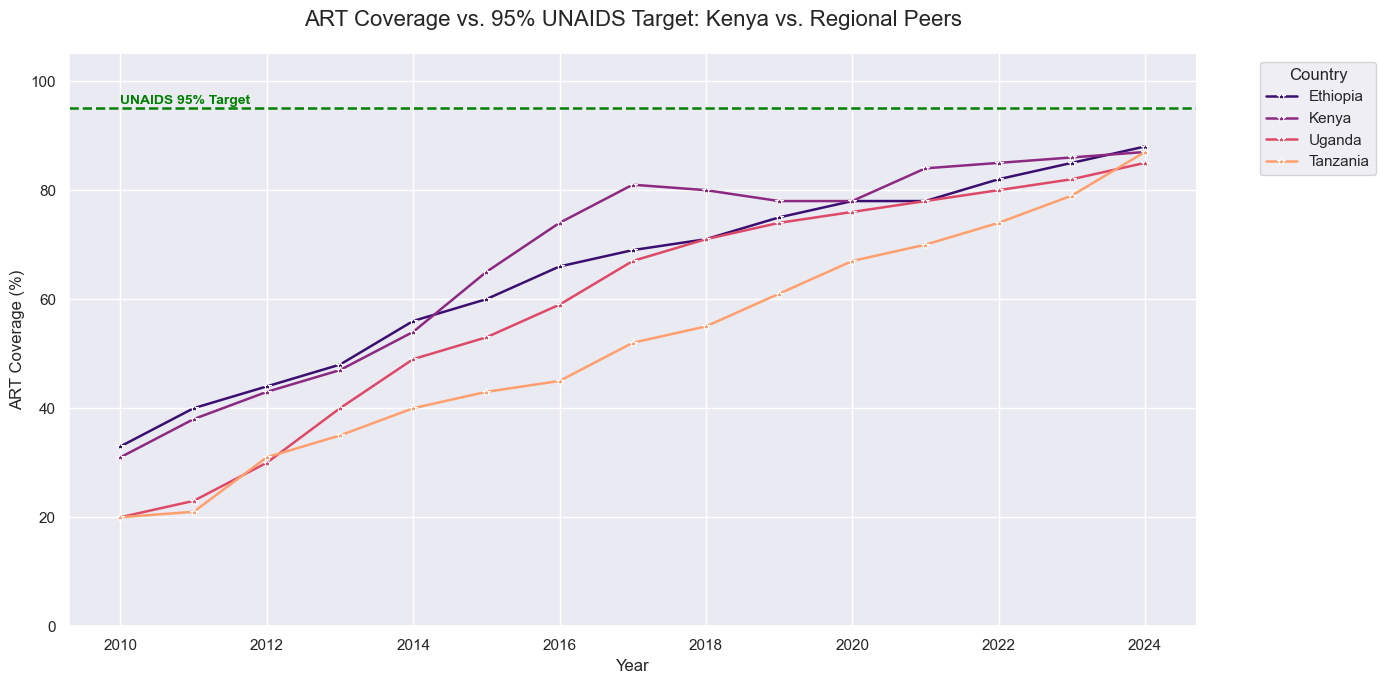

In [48]:
arv_coverage.reset_index(inplace=True)
plt.figure(figsize=(14,7))
sns.set_theme(style="darkgrid")

sns.lineplot(
    data = arv_coverage,
    x = 'Year',
    y = 'PLHIV_ARV(%)',
    hue = 'country',
    style='country',
    marker='*',
    palette = 'magma',
    dashes = False,
    linewidth=1.8,
    errorbar=None
)

plt.axhline(y=95,color='green',linestyle='--',linewidth=1.8)
plt.text(arv_coverage['Year'].min(),95.8,'UNAIDS 95% Target',color='green',fontsize=10,fontweight='bold')

plt.title("ART Coverage vs. 95% UNAIDS Target: Kenya vs. Regional Peers", fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("ART Coverage (%)", fontsize=12)
plt.ylim(0, 105)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig("ART_Coverage_overtime.png", dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()

All four countries demonstrate remarkable and sustained progress in ART coverage between 2010 and 2024, with coverage rising from the 20–34% range to approximately 85–88% across the board. Despite this impressive growth, no country has reached the UNAIDS 95% target by 2024, leaving a critical 7–10 percentage point gap still to close.

**Country-by-Country Performance**

**Ethiopia & Kenya — Joint Leaders (~88% by 2024)**

Both countries track almost identically throughout the period and are the closest to the 95% target. Kenya notably peaked at ~81% around 2016–2017 before experiencing a slight dip then recovery, possibly reflecting data revisions or disruptions in treatment continuity. By 2024 both converge at approximately 88%.

**Uganda (~87% by 2024)**

Uganda follows closely behind Ethiopia and Kenya, showing consistent and uninterrupted growth with no visible dips. Its trajectory is arguably the most stable of the four countries, reflecting sustained programmatic commitment.

**Tanzania — Slowest Start, Strongest Catch-up (~87% by 2024)**

Tanzania started furthest behind at just ~20% in 2010 — roughly 12 percentage points below its peers — but has shown the steepest rate of improvement of all four countries. By 2024 it has nearly caught up with the group, signalling a major acceleration in ART rollout, particularly post-2018.

In [49]:
kenya_peers.reset_index(drop=True, inplace=True)
arv_coverage.reset_index(drop=True, inplace=True)
# Merge the needed column in first, then calculate
arv_coverage = arv_coverage.merge(
    kenya_peers[['country', 'Year', 'total_hiv_pop']],
    on=['country', 'Year'],
    how='left'
)

arv_coverage['ART_gap'] = arv_coverage['total_hiv_pop'] * (95 - arv_coverage['PLHIV_ARV(%)']) / 100
arv_coverage.head()

,Year,code,country,PLHIV_ARV(%),total_hiv_pop,ART_gap
0,2010,ETH,Ethiopia,33,660000,409200.0
1,2010,KEN,Kenya,31,1400000,896000.0
2,2010,UGA,Uganda,20,1200000,900000.0
3,2010,TZA,Tanzania,20,1200000,900000.0
4,2011,ETH,Ethiopia,40,660000,363000.0


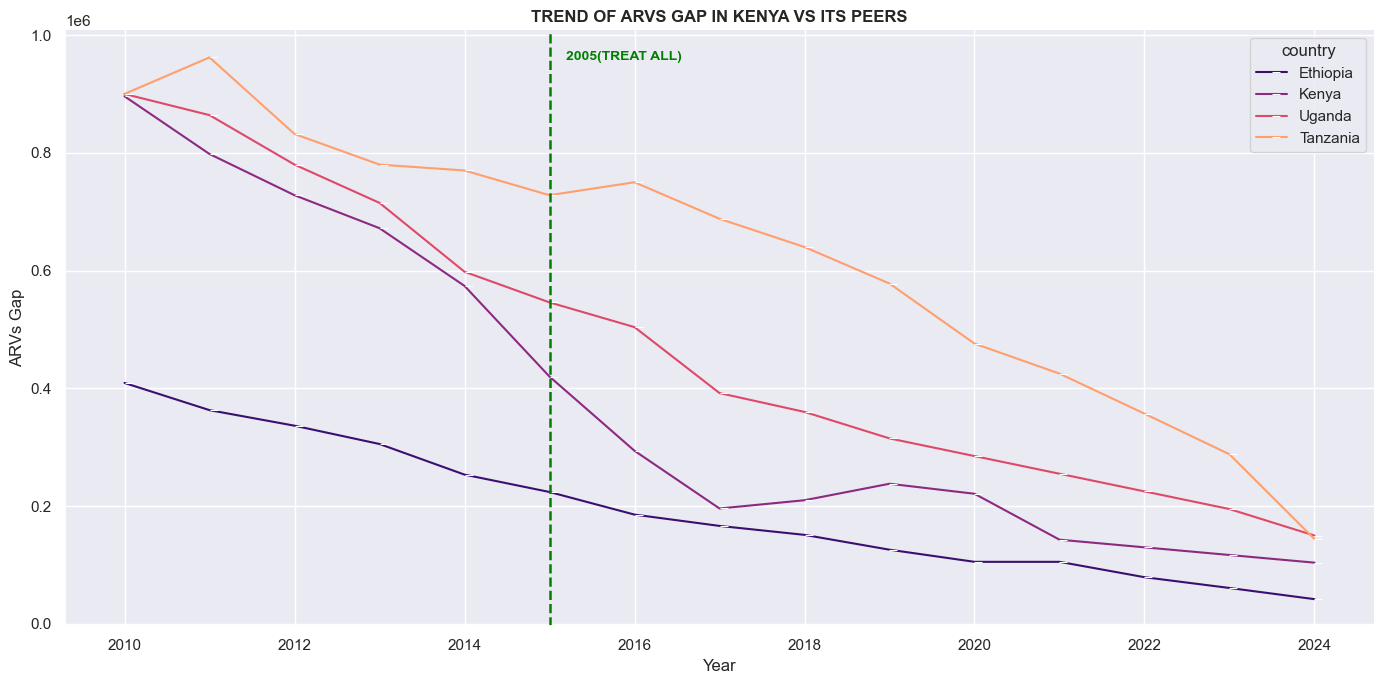

In [51]:
# ART GAP OVER THE YEARS FROM 2010 TO 2024
plt.figure(figsize=(14,7))
sns.set_theme(style='darkgrid')

sns.lineplot(
    data = arv_coverage,
    x = 'Year',
    y = 'ART_gap',
    hue = 'country',
    palette = 'magma',
    marker = True,
    dashes = False,
    errorbar = None
)
plt.axvline(x=2015,color='green',linewidth=1.8,linestyle='--')
plt.text(x=2015.2,y=plt.ylim()[1]*0.95,s='2005(TREAT ALL)',color='green',fontsize=10,fontweight='bold')
plt.title('TREND OF ARVS GAP IN KENYA VS ITS PEERS',fontweight='bold')
plt.xlabel("Year")
plt.ylabel("ARVs Gap")

sns.despine()
plt.tight_layout()
plt.savefig("ARVS GAP.png", dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()

The ARVs gap represents the number of people living with HIV who are NOT yet on antiretroviral treatment relative to the 95% UNAIDS target. A declining gap is positive — it means more people are being reached with treatment.

**Overall Trend**

All four countries show a consistent and significant decline in their ARVs gap across the entire 2010–2024 period. The introduction of the "Treat All" policy in 2015 — marked by the green dashed line — appears to have accelerated this decline, particularly for Uganda and Tanzania which had the largest gaps.

**Impact of the 2015 "Treat All" Policy**

The green dashed line marks the WHO's universal Treat All recommendation, which removed CD4 count eligibility thresholds and put all diagnosed PLHIV on treatment immediately. 


# FORECASTING

06:45:25 - cmdstanpy - INFO - Chain [1] start processing
06:45:26 - cmdstanpy - INFO - Chain [1] done processing


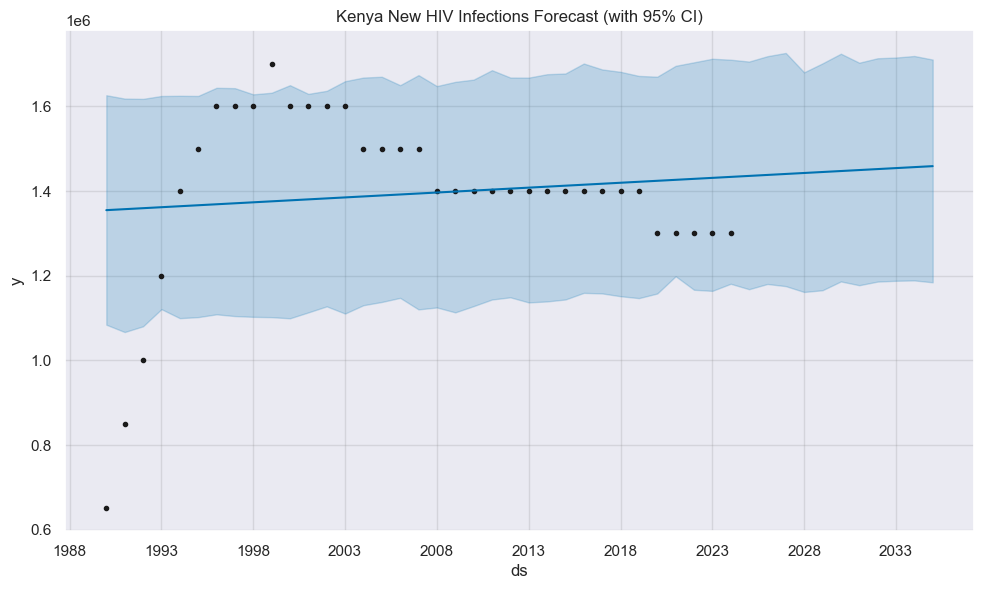

In [54]:
## Forecasting new infections in Kenya
# Example for Kenya new infections
ken_new = kenya_peers[kenya_peers['Code'] == 'KEN'][['Year', 'total_hiv_pop']].copy()
ken_new = ken_new.rename(columns={'Year': 'ds', 'total_hiv_pop': 'y'})
ken_new['ds'] = pd.to_datetime(ken_new['ds'], format='%Y')

m = Prophet(yearly_seasonality=False, uncertainty_samples=1000)
m.fit(ken_new)

future = m.make_future_dataframe(periods=11, freq='YE')   # to 2035
forecast = m.predict(future)

fig = m.plot(forecast)
plt.title('Kenya New HIV Infections Forecast (with 95% CI)')
plt.savefig("Kenya_newinfections_forecast.png", dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show();